height of track

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [82]:
h = np.array([11.1, 12.8, 11.5, 12.8, 12.7])
err_h = 0.05

print(np.mean(h))
error_mean = np.std(h, ddof=1)/np.sqrt(len(h))
print(error_mean)
print(np.sqrt(error_mean**2 + err_h**2))


12.180000000000001
0.3652396473549936
0.3686461718233353


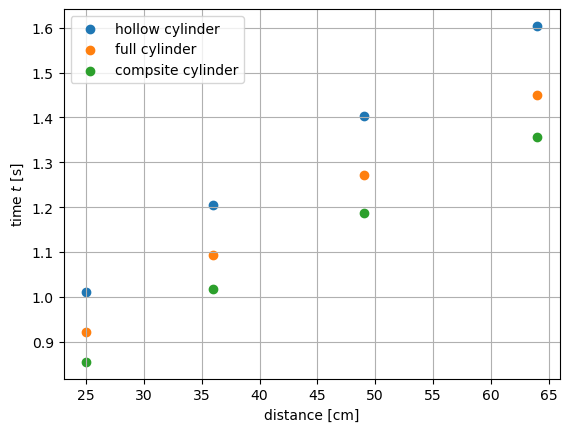

In [83]:
t_hollow = np.array([1.011, 1.204, 1.403, 1.604])
t_full = np.array([0.921, 1.094, 1.272, 1.451])
t_compose = np.array([0.855, 1.018, 1.186, 1.356])

x = np.array([25, 36, 49, 64])

plt.scatter(x, t_hollow, label="hollow cylinder")
plt.scatter(x, t_full, label="full cylinder")
plt.scatter(x, t_compose, label="compsite cylinder")
plt.xlabel("distance [cm]")
plt.ylabel("time $t$ [s]")
plt.grid(True)
plt.legend()

Quantitative
A3: 

In [84]:
x = np.array([25, 36, 49, 64])

t_hollow = np.array([
    [1.019, 1.212, 1.410, 1.610],
    [1.027, 1.223, 1.426, 1.629],
    [1.014, 1.209, 1.410, 1.613],
    [1.022, 1.215, 1.415, 1.614],
    [1.009, 1.201, 1.400, 1.600]
])
t_full = np.array([
    [0.922, 1.096, 1.278, 1.459],
    [0.893, 1.068, 1.245, 1.425],
    [0.900, 1.075, 1.255, 1.435],
    [0.901, 1.074, 1.254, 1.435],
    [0.913, 1.087, 1.266, 1.446]
])

mean_hollow = np.mean(t_hollow, axis=0)
std_hollow = np.std(t_hollow, axis=0, ddof=1)/np.sqrt(t_hollow.shape[0])  # Standard error of the mean
mean_full = np.mean(t_full, axis=0)
std_full = np.std(t_full, axis=0, ddof=1)/np.sqrt(t_full.shape[0])  # Standard error of the mean

print("Hollow cylinder:")
for distance, mean, std in zip(x, mean_hollow, std_hollow):
    print(f"{distance} cm: mean = {mean:.4f} s, std = {std:.4f} s")

print("\nFull cylinder:")
for distance, mean, std in zip(x, mean_full, std_full):
    print(f"{distance} cm: mean = {mean:.4f} s, std = {std:.4f} s")

Hollow cylinder:
25 cm: mean = 1.0182 s, std = 0.0031 s
36 cm: mean = 1.2120 s, std = 0.0036 s
49 cm: mean = 1.4122 s, std = 0.0042 s
64 cm: mean = 1.6132 s, std = 0.0047 s

Full cylinder:
25 cm: mean = 0.9058 s, std = 0.0052 s
36 cm: mean = 1.0800 s, std = 0.0050 s
49 cm: mean = 1.2596 s, std = 0.0057 s
64 cm: mean = 1.4400 s, std = 0.0058 s


a4

In [85]:
# messung, t1, t2

# hollow
m1h = np.array([1.922, 2.192])
m2h = np.array([1.951, 2.222])  
m3h = np.array([1.936, 2.206])
m4h = np.array([1.922, 2.192])
m5h = np.array([1.938, 2.207])

# full
m1f = np.array([1.724, 1.967])
m2f = np.array([1.736, 1.980])
m3f = np.array([1.718, 1.961])
m4f = np.array([1.737, 1.981])
m5f = np.array([1.749, 1.992])

m_diff_h = np.array([])
for i in [m1h, m2h, m3h, m4h, m5h]:
    m_diff_h = np.append(m_diff_h, i[1] - i[0])
    
m_diff_f = np.array([])
for i in [m1f, m2f, m3f, m4f, m5f]:
    m_diff_f = np.append(m_diff_f, i[1] - i[0])

err_t = 0.001
print("Hollow cylinder time differences:")
print(m_diff_h)
print("Mean time difference for hollow cylinder:", np.mean(m_diff_h))
print("Standard error for hollow cylinder:", np.std(m_diff_h, ddof=1)/len(m_diff_h))
print('Full error for hollow cylinder:', np.sqrt((np.std(m_diff_h, ddof=1)/len(m_diff_h))**2 + err_t**2))

print("\nFull cylinder time differences:")

print(m_diff_f)
print("Mean time difference for full cylinder:", np.mean(m_diff_f))
print("Standard error for full cylinder:", np.std(m_diff_f, ddof=1)/len(m_diff_f))
print('Full error for full cylinder:', np.sqrt((np.std(m_diff_f, ddof=1)/len(m_diff_f))**2 + err_t**2))



Hollow cylinder time differences:
[0.27  0.271 0.27  0.27  0.269]
Mean time difference for hollow cylinder: 0.2700000000000001
Standard error for hollow cylinder: 0.00014142135623730964
Full error for hollow cylinder: 0.0010099504938362077

Full cylinder time differences:
[0.243 0.244 0.243 0.244 0.243]
Mean time difference for full cylinder: 0.2434
Standard error for full cylinder: 0.00010954451150102927
Full error for full cylinder: 0.001005982107196743


Examination


In [86]:
import uncertainties as unc
import uncertainties.unumpy as unp

In [87]:
m = unc.ufloat(443, 1) * 1e-3      # mass in kg
d_outer = unc.ufloat(50, 0.05) * 1e-3  # outer diameter in m
d_inner = unc.ufloat(46.5, 0.05) * 1e-3 # inner diameter in m

I_hollow = (1/2) * m * ((d_outer/2)**2 + (d_inner/2)**2)
I_full = (1/2) * m * (d_outer/2)**2

print(f"Hollow cylinder moment of inertia: {I_hollow:.7e} kgm²")
print(f"Solid cylinder moment of inertia: {I_full:.7e} kgm²")

h = unc.ufloat(10.1, 0.4)*1e-2  # height in m
l = unc.ufloat(1.000, 0.005)  # length in m\
    
varphi = unp.arcsin(h / l)
varphi_deg = varphi * 180 / np.pi
print(f"Angle of inclination: {varphi_deg:.3f} degrees, {varphi:.4f} radians")

Hollow cylinder moment of inertia: (2.5817209+/-0.0069469)e-04 kgm²
Solid cylinder moment of inertia: (1.3843750+/-0.0041751)e-04 kgm²
Angle of inclination: 5.797+/-0.232 degrees, 0.1012+/-0.0041 radians


In [88]:
a_solid = (9.81 * unp.sin(varphi)) / (1 + I_full / (m * (d_outer/2)**2))
a_hollow = (9.81 * unp.sin(varphi)) / (1 + I_hollow / (m * (d_outer/2)**2))

print(a_solid)
print(a_hollow)


0.661+/-0.026
0.513+/-0.020


Plot the values in Diagram

Full cylinder fit parameters: slope = 0.6161 $\pm$ 0.0029
Hollow cylinder fit parameters: slope = 0.4892 $\pm$ 0.0015


<>:22: SyntaxWarning: invalid escape sequence '\,'
<>:23: SyntaxWarning: invalid escape sequence '\,'
<>:22: SyntaxWarning: invalid escape sequence '\,'
<>:23: SyntaxWarning: invalid escape sequence '\,'
/var/folders/9r/ppvq7f7j3kv69gnk_v549lcm0000gn/T/ipykernel_18719/668146309.py:22: SyntaxWarning: invalid escape sequence '\,'
  plt.plot(x_fit, func(x_fit, popt_full[0]), label=f"Fit Full Cylinder $a = {popt_full[0]:.4f}\, m/s^2$", color='red')
/var/folders/9r/ppvq7f7j3kv69gnk_v549lcm0000gn/T/ipykernel_18719/668146309.py:23: SyntaxWarning: invalid escape sequence '\,'
  plt.plot(x_fit, func(x_fit, popt_hollow[0]), label=f"Fit Hollow Cylinder $a = {popt_hollow[0]:.4f}\, m/s^2$", color='lightblue')


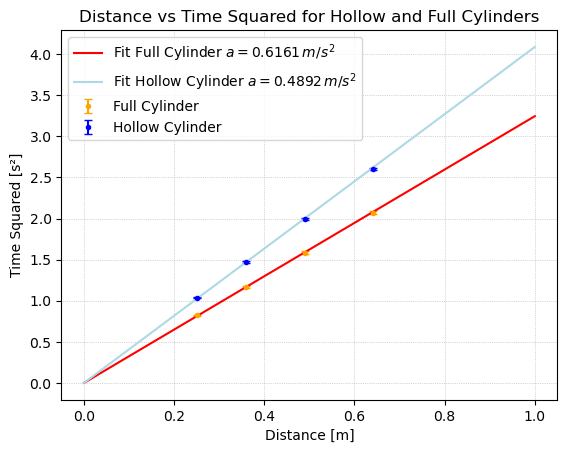

In [89]:

mean_hollow_squared = mean_hollow**2
std_hollow_squared = np.sqrt(std_hollow**2 + 0.001**2) * mean_hollow * 2
mean_full_squared = mean_full**2
std_full_squared = np.sqrt(std_full**2 + 0.001**2) * mean_full * 2

s = np.array([25, 36, 49, 64])*1e-2     



plt.errorbar(s, mean_full_squared, yerr=std_full_squared, fmt='.', label="Full Cylinder", capsize=3, color='orange')

plt.errorbar(s, mean_hollow_squared, yerr=std_hollow_squared, fmt='.', label="Hollow Cylinder", capsize=3, color='blue')



func = lambda x, a: (2.0 / a) * x

popt_hollow, pcov_hollow = curve_fit(func, s, mean_hollow_squared, sigma=std_hollow_squared, absolute_sigma=True)
popt_full, pcov_full = curve_fit(func, s, mean_full_squared, sigma=std_full_squared, absolute_sigma=True)

x_fit = np.linspace(0, 1, 100)
plt.plot(x_fit, func(x_fit, popt_full[0]), label=f"Fit Full Cylinder $a = {popt_full[0]:.4f}\, m/s^2$", color='red')
plt.plot(x_fit, func(x_fit, popt_hollow[0]), label=f"Fit Hollow Cylinder $a = {popt_hollow[0]:.4f}\, m/s^2$", color='lightblue')

plt.xlabel("Distance [m]")
plt.ylabel("Time Squared [s²]")
plt.grid(which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.title("Distance vs Time Squared for Hollow and Full Cylinders")
print(f"Full cylinder fit parameters: slope = {popt_full[0]:.4f} $\\pm$ {np.sqrt(pcov_full[0][0]):.4f}")
print(f"Hollow cylinder fit parameters: slope = {popt_hollow[0]:.4f} $\\pm$ {np.sqrt(pcov_hollow[0][0]):.4f}")


Fitted the other way around

<>:18: SyntaxWarning: invalid escape sequence '\,'
<>:19: SyntaxWarning: invalid escape sequence '\,'
<>:18: SyntaxWarning: invalid escape sequence '\,'
<>:19: SyntaxWarning: invalid escape sequence '\,'
/var/folders/9r/ppvq7f7j3kv69gnk_v549lcm0000gn/T/ipykernel_18719/3647935948.py:18: SyntaxWarning: invalid escape sequence '\,'
  plt.plot(x_fit, func(x_fit, *popt_full), label=f'Fit Full Cylinder $a = {popt_full[0]:.4f}\, m/s^2$', color='red')
/var/folders/9r/ppvq7f7j3kv69gnk_v549lcm0000gn/T/ipykernel_18719/3647935948.py:19: SyntaxWarning: invalid escape sequence '\,'
  plt.plot(x_fit, func(x_fit, *popt_hollow), label=f'Fit Hollow Cylinder $a = {popt_hollow[0]:.4f}\, m/s^2$' , color='lightblue')


Full cylinder fit parameters: a = 0.6168 $\pm$ 0.0034, c = 0
Hollow cylinder fit parameters: a = 0.4907 $\pm$ 0.0027, c = 0


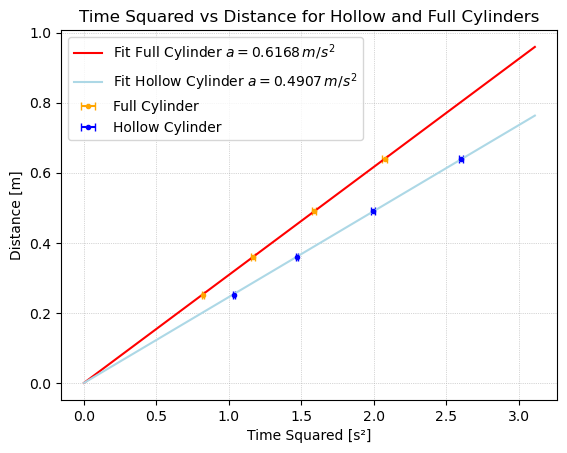

In [93]:


mean_hollow_squared = mean_hollow**2
std_hollow_squared = np.sqrt(std_hollow**2 + 0.001**2) * mean_hollow * 2
mean_full_squared = mean_full**2
std_full_squared = np.sqrt(std_full**2 + 0.001**2) * mean_full * 2

s = np.array([25, 36, 49, 64]) * 1e-2

plt.errorbar(mean_full_squared, s, xerr=std_full_squared, fmt='.', label='Full Cylinder', capsize=3, color='orange')
plt.errorbar(mean_hollow_squared, s, xerr=std_hollow_squared, fmt='.', label='Hollow Cylinder', capsize=3, color='blue')

# keep the same model form y = a*x + c, but fix c = 0
func = lambda x, a, c=0: (a / 2.0) * x + c

popt_hollow, pcov_hollow = curve_fit(func, mean_hollow_squared, s, sigma=np.full_like(s, 0.005), absolute_sigma=True, p0=[1.0], bounds=([-np.inf], [np.inf]))
popt_full, pcov_full = curve_fit(func, mean_full_squared, s, sigma=np.full_like(s, 0.005), absolute_sigma=True, p0=[1.0], bounds=([-np.inf], [np.inf]))

x_fit = np.linspace(0, np.max(mean_full_squared) * 1.5, 100)
plt.plot(x_fit, func(x_fit, *popt_full), label=f'Fit Full Cylinder $a = {popt_full[0]:.4f}\, m/s^2$', color='red')
plt.plot(x_fit, func(x_fit, *popt_hollow), label=f'Fit Hollow Cylinder $a = {popt_hollow[0]:.4f}\, m/s^2$' , color='lightblue')

plt.xlabel('Time Squared [s²]')
plt.ylabel('Distance [m]')
plt.grid(which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.title('Time Squared vs Distance for Hollow and Full Cylinders')
print(f'Full cylinder fit parameters: a = {popt_full[0]:.4f} $\\pm$ {np.sqrt(pcov_full[0][0]):.4f}, c = 0')
print(f'Hollow cylinder fit parameters: a = {popt_hollow[0]:.4f} $\\pm$ {np.sqrt(pcov_hollow[0][0]):.4f}, c = 0')


Calculate Height

In [ ]:

d = unc.ufloat(11, 0.5)*1e-3  # dist start in m

h = h/l * (l-d)
print('delta h in m:', h)

delta h in m: 0.100+/-0.004


In [ ]:
E = m * 9.81 * h
E

0.43410061287+/-0.01722142256704715

In [ ]:
m_diff_f
err_f = np.sqrt((np.std(m_diff_f, ddof=1)/len(m_diff_f))**2 + err_t**2)

m_diff_h
err_h = np.sqrt((np.std(m_diff_h, ddof=1)/len(m_diff_h))**2 + err_t**2)

d = unc.ufloat(25, 0.07)*1e-2  # dist between light barriers in m

t_f = unc.ufloat(np.mean(m_diff_f), err_f)
t_h = unc.ufloat(np.mean(m_diff_h), err_h)


v_f = d / t_f
v_h = d / t_h

r = d_outer / 2


print(f"Full cylinder speed: {v_f:.4f} m/s")
print(f"Hollow cylinder speed: {v_h:.4f} m/s")

w_f = v_f / r
print(f"Full cylinder angular velocity: {w_f:.4f} rad/s")
w_h = v_h / r
print(f"Hollow cylinder angular velocity: {w_h:.4f} rad/s")


E_trans_f = 1/2 * m * v_f**2
E_rot_f = 1/2 * I_full * w_f**2

E_trans_h = 1/2 * m * v_h**2
E_rot_h = 1/2 * I_hollow * w_h**2

print(f"\nFull cylinder translational kinetic energy: {E_trans_f:.5f} J")
print(f"Full cylinder rotational kinetic energy: {E_rot_f:.5f} J")
print(f"total kinetic energy: {E_trans_f + E_rot_f:.5f} J")
print(f"\nHollow cylinder translational kinetic energy: {E_trans_h:.5f} J")
print(f"Hollow cylinder rotational kinetic energy: {E_rot_h:.5f} J")
print(f"total kinetic energy: {E_trans_h + E_rot_h:.5f} J")


Full cylinder speed: 1.0271+/-0.0051 m/s
Hollow cylinder speed: 0.9259+/-0.0043 m/s
Full cylinder angular velocity: 41.0846+/-0.2092 rad/s
Hollow cylinder angular velocity: 37.0370+/-0.1770 rad/s

Full cylinder translational kinetic energy: 0.23368+/-0.00239 J
Full cylinder rotational kinetic energy: 0.11684+/-0.00120 J
total kinetic energy: 0.35051+/-0.00359 J

Hollow cylinder translational kinetic energy: 0.18990+/-0.00183 J
Hollow cylinder rotational kinetic energy: 0.17707+/-0.00172 J
total kinetic energy: 0.36697+/-0.00354 J
